### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd



In [60]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)


In [62]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [48]:
# pipeline predictions
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)

In [63]:
# create y_pred based on ES percent cols
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [64]:
# create a dataset containing results for confusion matrix

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']

conf_mtrx_df

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,6,3
1,Chile_Sustainable_Bond_Framework,manual,Table,EN,0.65,0.65,ES 0%,ES partial,0,8
2,Genneia_Green_Financing_Framework,manual,Table,EN,0.65,0.65,ES partial,ES 100%,5,1
3,Marco_de_Uso_de_Fondo_para_la_Emision_de_Bonos...,manual,Table,ES,0.65,0.65,ES partial,ES 100%,7,1
4,Green_Bond_Framework,manual,Table,PT,0.65,0.65,ES partial,ES partial,13,2
5,Green_Bonds_Framework_Athon_2020,manual,UOP_section_true,PT,0.65,0.65,ES partial,ES partial,4,9
6,Cartilla_Bonos_Verdes,manual,UOP_section_true,ES,0.65,0.65,ES 0%,ES partial,0,10
7,Bono_Azul_-_Framework,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES 0%,6,5
8,Marco_de_referencia_de_bono_verde_Coopeguanaca...,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,8,9
9,Marco_de_Referencia_del_Bono_Verde_de_la_Ciuda...,manual,UOP_section_false,ES,0.65,0.65,ES partial,ES partial,17,10


In [ ]:
# create ES Partial TP col based on ES percent cols
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df

In [55]:
# bring in data from eval

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[28,  2],
        [ 4,  0]],

       [[20,  3],
        [10,  1]],

       [[ 1, 14],
        [ 5, 14]]])

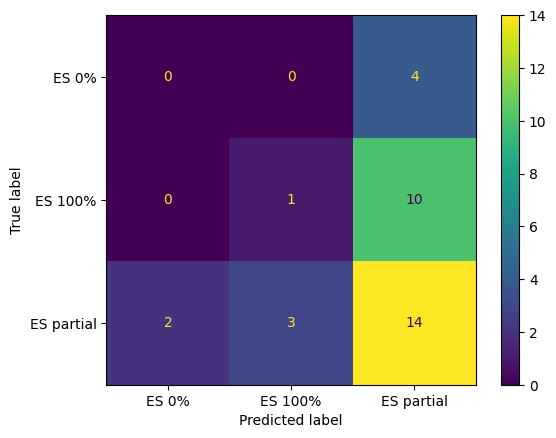

In [52]:
cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

In [56]:
accuracy_score_frac = accuracy_score(y_true, y_pred)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)

print(accuracy_score_frac, accuracy_score_num)

f1_score(y_true, y_pred, average='macro')

0.4411764705882353 15.0


0.24302600472813238

In [58]:
# create a dataset containing results for boxplots

boxplots_df = pd.DataFrame()

boxplots_df['pdfname'] = pred_train_df['pdfname']
boxplots_df['gt_source'] = gt_train_df['gt_source']
boxplots_df['nlp_path'] = pred_train_df['nlp_path']
boxplots_df['language'] = pred_train_df['language']
boxplots_df['similarity_th'] = pred_train_df['similarity_threshold']
boxplots_df['cleanup_th'] = pred_train_df['cleanup_threshold']



In [42]:

pdf_name = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q']
ppl = ['UOP section', 'UOP section', 'Table', 'UOP section', 'Table', 'Table', 'UOP section', 'Table','UOP section',
       'UOP section','UOP section','Table','Table','Table','UOP section','UOP section','Table']
yy_true = [6,5,7,13,4,6,8,17,3,2,2,4,2,2,8,8,2]
yy_pred = [7,10,6,10,3,4,10,8,4,7,7,2,3,2,10,10,2]
yy_diffs = [1,5,-1,-3,-1,-2,2,-9,1,5,5,-2,1,0,2,2,0]
num_cats_df = pd.DataFrame()
num_cats_df['pdf_name'] = pdf_name
num_cats_df['ppl'] = ppl
num_cats_df['yy_true'] = yy_true
num_cats_df['yy_pred'] = yy_pred
num_cats_df['yy_diffs'] = yy_diffs

num_cats_df.set_index('pdf_name')
num_cats_df

,pdf_name,ppl,yy_true,yy_pred,yy_diffs
0,A,UOP section,6,7,1
1,B,UOP section,5,10,5
2,C,Table,7,6,-1
3,D,UOP section,13,10,-3
4,E,Table,4,3,-1
5,F,Table,6,4,-2
6,G,UOP section,8,10,2
7,H,Table,17,8,-9
8,I,UOP section,3,4,1
9,J,UOP section,2,7,5


<Axes: xlabel='yy_diffs', ylabel='ppl'>

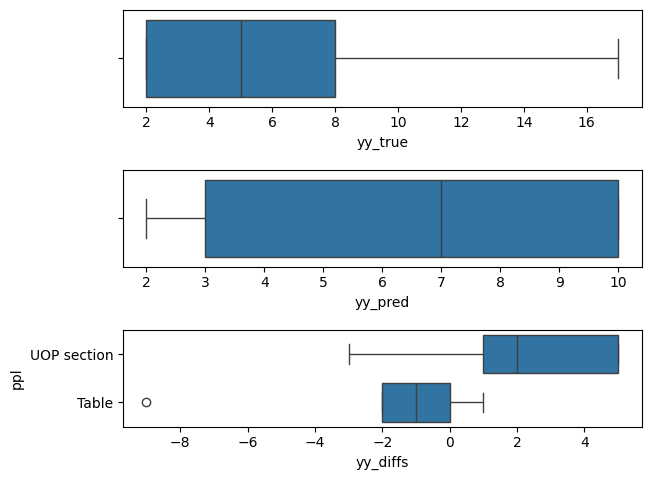

In [43]:
fig, axes = plt.subplots(3,1, layout='constrained')
fig.set_constrained_layout_pads(h_pad = 0.1)
sns.boxplot(x=num_cats_df['yy_true'], ax=axes[0])
sns.boxplot(x=num_cats_df['yy_pred'], ax=axes[1])
sns.boxplot(x=num_cats_df['yy_diffs'], y = num_cats_df['ppl'], ax=axes[2])